# 투자성과 지표(백테스트)

* 단일 종목 일간수익률
* 단일 종목 누적수익률
* CAGR
* MDD
* Sharpe ratio

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = {'close': [100, 95, 101, 103, 90, 95, 110, 98, 101]} # 9일 간 가격 데이터,
index = pd.to_datetime(["2025-12-17", "2025-12-18" , "2025-12-19", "2025-12-20", "2025-12-23", "2025-12-24", "2025-12-25", "2025-12-26", "2025-12-27"])
df = pd.DataFrame(data=data, index=index) # 데이터 프레임 생성
df

,close
2025-12-17,100
2025-12-18,95
2025-12-19,101
2025-12-20,103
2025-12-23,90
2025-12-24,95
2025-12-25,110
2025-12-26,98
2025-12-27,101


<Axes: >

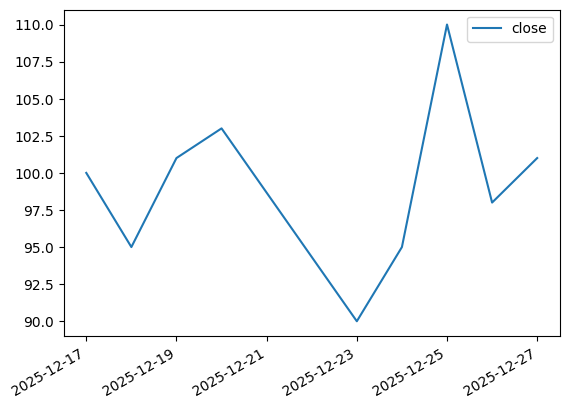

In [ ]:
df.plot()

### 단일종목 일간 수익률

일간 수익률 = `당기 가격 / 전기 가격` 으로 계산할 수 있습니다.  
판다스의 `shift 메서드`를 이용해서 간편하게 계산할 수 있습니다.  
`shift(n)` 메서드는 `n`만큼 아래로 이동시키는 기능을 합니다.

In [ ]:
df.shift(1)

,close
2025-12-17,NaN
2025-12-18,100.0
2025-12-19,95.0
2025-12-20,101.0
2025-12-23,103.0
2025-12-24,90.0
2025-12-25,95.0
2025-12-26,110.0
2025-12-27,98.0


In [ ]:
dayReturn = df / df.shift(1)
dayReturn

,close
2025-12-17,NaN
2025-12-18,0.950000
2025-12-19,1.063158
2025-12-20,1.019802
2025-12-23,0.873786
2025-12-24,1.055556
2025-12-25,1.157895
2025-12-26,0.890909
2025-12-27,1.030612


간단하게 일간 수익률을 구했습니다. 다만, 첫번째 수익률은 1로 해주면 되겠죠.  
`fillna()` 메서드를 사용하면 nan를 원하는 값으로 바꿀 수 있습니다.

In [ ]:
dayReturn = (df / df.shift(1)).fillna(1)
dayReturn

,close
2025-12-17,1.000000
2025-12-18,0.950000
2025-12-19,1.063158
2025-12-20,1.019802
2025-12-23,0.873786
2025-12-24,1.055556
2025-12-25,1.157895
2025-12-26,0.890909
2025-12-27,1.030612


### 단일종목 누적 수익률

주가의 움직임은 복리입니다.  
일간 수익률을 누적곱해주면 누적 수익률을 구할 수 있습니다.  
`cumprod()`메서드를 사용하면 누적곱을 구할 수 있습니다.



In [ ]:
cumulativeReturn = dayReturn.cumprod()
cumulativeReturn

,close
2025-12-17,1.00
2025-12-18,0.95
2025-12-19,1.01
2025-12-20,1.03
2025-12-23,0.90
2025-12-24,0.95
2025-12-25,1.10
2025-12-26,0.98
2025-12-27,1.01


  *누적수익률은 마지막날의 가격을 첫날 가격으로 나눠서 계산 가능합니다.

### CAGR (compound annual growth rate)
우리는 일간 수익률을 연간 수익률로 환산하기 때문에 아래 공식을 사용합니다.

일간 수익률을 연간 수익률(Annualized Return)로 환산하는 가장 정확한 방법은 **'복리(Compounding)'** 개념을 적용하는 것입니다.

단순히 곱하기를 하는 것이 아니라, "매일 번 돈이 재투자되어 불어난다"는 가정하에 계산해야 합니다.

### 핵심 공식
  $$\text{연간 수익률} = (1 + \text{일간 평균 수익률})^{252} - 1$$

* **252의 의미:** 1년 중 주말과 공휴일을 뺀 실제 **'주식 거래일(Trading Days)'**이 평균적으로 약 252일이기 때문입니다. (암호화폐는 365를 사용합니다.)
* **원리:** 하루에 1%씩 252일 동안 매일 복리로 오르면, , 즉 12배가 넘게 됩니다. (단순 합산인 252%와는 차원이 다릅니다.)



In [ ]:
len(df)

9

In [ ]:
cumulativeReturn.iloc[-1]

,2025-12-27
close,1.01


In [ ]:
cagr = cumulativeReturn.iloc[-1]  ** (252 / len(df))
cagr

,2025-12-27
close,1.321291


### Draw Down (하락폭) && Max Draw Down (최대하락폭)

최대 낙폭지수,투자 기간 동안 고점부터 떨어진 낙폭 최댓값을 의미합니다.  
최종 수익률만 보고 판단하기 쉬운데, 사실 투자 기간동안 50%가 빠지면 심리적 타격도 있기 때문에 손절하고 투자를 중단할 수도 있습니다.  
그렇기 때문에 최대 낙폭은 가능한 낮을수록 좋습니다.

하락폭(DD) = $ \frac{최고점 - 현재}{최고점} $  
최대하락폭(MDD) = max ($ \frac{최고점 - 현재}{최고점} $)

Pandas의 `cummax()` 메서드를 사용하면 데이터를 위에서부터 아래로 조회하며 최대값을 갱신합니다.

In [ ]:
cumulativeReturn

,close
2022-05-17,1.00
2022-05-18,0.95
2022-05-19,1.01
2022-05-20,1.03
2022-05-23,0.90
2022-05-24,0.95
2022-05-25,1.10
2022-05-26,0.98
2022-05-27,1.01


In [ ]:
cumulativeReturn.cummax()

,close
2022-05-17,1.00
2022-05-18,1.00
2022-05-19,1.01
2022-05-20,1.03
2022-05-23,1.03
2022-05-24,1.03
2022-05-25,1.10
2022-05-26,1.10
2022-05-27,1.10


**MDD 계산**

In [ ]:
dd = (cumulativeReturn.cummax() - cumulativeReturn) / cumulativeReturn.cummax() * 100
dd

,close
2025-12-17,0.000000
2025-12-18,5.000000
2025-12-19,0.000000
2025-12-20,0.000000
2025-12-23,12.621359
2025-12-24,7.766990
2025-12-25,0.000000
2025-12-26,10.909091
2025-12-27,8.181818


In [ ]:
mdd = dd.max()
mdd

,0
close,12.621359


##Sharpe ratio 지수

투자 자산이 감수한 '위험(변동성) 한 단위당' 얼마의 '초과 수익'을 냈는지 평가하는 지표입니다.

단순히 최종 수익률만 높다고 좋은 투자가 아닙니다. 수익률이 100%라도 도중에 반토막이 나는 등 등락이 너무 심했다면(위험이 컸다면), 운이 좋아서 번 것일 수 있습니다.반면 안정적으로 우상향했다면 실력이 좋은 것입니다.

그렇기 때문에 샤프 지수는 높을수록(보통 1 이상) 위험 대비 성과가 뛰어난 '가성비 좋은' 투자입니다.

수식:$$\text{샤프 지수} = \frac{\text{포트폴리오 수익률} - \text{무위험 이자율}}{\text{수익률의 표준편차(변동성)}}$$

-포트폴리오 수익률: 내 전략의 연평균 수익률

-무위험 이자율: 은행 예금이나 미국 국채처럼 위험 없이 얻을 수 있는 기본 수익률 (보통 2~3% 적용하거나 0으로 가정)

-표준편차: 수익률이 평균에서 얼마나 들쭉날쭉했는지 나타내는 변동성 지표

In [ ]:
data = {'close': [100, 80, 95, 120, 140, 125, 110, 155, 170]} # 9일 간 가격 데이터,
index = pd.to_datetime(["2025-12-17", "2025-12-18" , "2025-12-19", "2025-12-20", "2025-12-23", "2025-12-24", "2025-12-25", "2025-12-26", "2025-12-27"])
df = pd.DataFrame(data=data, index=index) # 데이터 프레임 생성
df

,close
2025-12-17,100
2025-12-18,80
2025-12-19,95
2025-12-20,120
2025-12-23,140
2025-12-24,125
2025-12-25,110
2025-12-26,155
2025-12-27,170


In [ ]:
# [일간 수익률 계산
# 공식: (오늘가격 - 어제가격) / 어제가격
df['daily_return'] = df['close'].pct_change()

# 보기 편하게 % 단위로 변환해서 출력해 봅니다
print(df[['close', 'daily_return']])


            close  daily_return
2025-12-17    100           NaN
2025-12-18     80     -0.200000
2025-12-19     95      0.187500
2025-12-20    120      0.263158
2025-12-23    140      0.166667
2025-12-24    125     -0.107143
2025-12-25    110     -0.120000
2025-12-26    155      0.409091
2025-12-27    170      0.096774


In [ ]:
# [Step 3] 무위험 이자율 설정 (Risk-Free Rate)
# 가정: 연 2% 수익률을 무위험으로 가정

annual_rf = 0.02
daily_rf = annual_rf / 252

print(f"연간 기준: {annual_rf * 100}%")
print(f"일간 환산: {daily_rf:.6f} (약 {daily_rf*100:.4f}%)")

연간 기준: 2.0%
일간 환산: 0.000079 (약 0.0079%)


In [ ]:
# 초과 수익률 계산
# 공식: 일간 수익률 - 일간 무위험 이자율

df['excess_return'] = df['daily_return'] - daily_rf
print(df[['daily_return', 'excess_return']])

            daily_return  excess_return
2025-12-17           NaN            NaN
2025-12-18     -0.200000      -0.200079
2025-12-19      0.187500       0.187421
2025-12-20      0.263158       0.263079
2025-12-23      0.166667       0.166587
2025-12-24     -0.107143      -0.107222
2025-12-25     -0.120000      -0.120079
2025-12-26      0.409091       0.409012
2025-12-27      0.096774       0.096695


In [ ]:
# 평균 및 표준편차 계산
# 주의: 첫 번째 행의 NaN을 제외하고 계산해야 함
# 판다스의 통계 함수들(mean, std, sum 등)은 기본적으로 skipna=True 라는 옵션이 있음
mean_excess = df['excess_return'].mean()
std_excess = df['excess_return'].std()

print(f"초과 수익률 평균 (Mean): {mean_excess:.5f}")
print(f"초과 수익률 변동성 (Std): {std_excess:.5f}")

초과 수익률 평균 (Mean): 0.08693
초과 수익률 변동성 (Std): 0.21187


In [ ]:
# 샤프 지수 계산
# 공식: (평균 초과 수익률 / 수익률의 표준편차) * sqrt(252)
daily_sharpe = mean_excess / std_excess
annual_sharpe = daily_sharpe * np.sqrt(252)

# 월간 샤프 지수 (일간 x √21일)
# sharpe_monthly = sharpe_daily * np.sqrt(21)

print(f"일간 샤프 지수: {daily_sharpe:.4f}")
print(f"연간 샤프 지수: {annual_sharpe:.4f}")

일간 샤프 지수: 0.4103
연간 샤프 지수: 6.5130
